# Class 05 — How Science Works
**DSC 215 · Statistical Critical Thinking & Experimental Design · UCSD**

*Based on Science Fictions, Chapter 1 — Stuart Ritchie*

---

This class is conceptual — but each concept has quantitative structure. We simulate citation inequality, model peer review as a noisy classifier, connect Mertonian norms to Ioannidis' PPV framework, taxonomize famous mistakes by failure mode, and quantify Popper's falsifiability principle. The final section maps every course class to the scientific failure it prevents.

**Contents:**
1. [Setup](#1)
2. [Citation Distributions — The Popularity Paradox](#2)
3. [Peer Review as a Noisy Classifier](#3)
4. [Mertonian Norms → PPV: What Violations Actually Cost](#4)
5. [Famous Scientific Mistakes — Failure Mode Taxonomy](#5)
6. [Popper's Falsifiability — Quantified](#6)
7. [Course Synthesis](#7)

---

<a id='1'></a>
## 1. Setup

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
np.random.seed(42)
plt.rcParams.update({'figure.dpi':120,'font.family':'DejaVu Sans',
                     'axes.spines.top':False,'axes.spines.right':False,
                     'axes.titlesize':13,'axes.labelsize':11})
BLUE='#2563EB'; RED='#DC2626'; GREEN='#16A34A'; ORANGE='#D97706'; GRAY='#6B7280'; PURPLE='#7C3AED'
print('Ready.')

Ready.


<a id='2'></a>
## 2. Citation Distributions — The Popularity Paradox

The slides say citation count is a good measure of popularity. True — but citation distributions follow a **power law** (Lotka's Law): a tiny fraction of papers get nearly all citations. This means a paper cited once already outranks the majority of published work.

In [6]:
n_papers = 10000
citations = np.random.zipf(2.5, n_papers)
citations = np.clip(citations, 0, 5000)

print(f"Citation distribution ({n_papers:,} papers)")
print(f"  Mean:        {citations.mean():.1f}")
print(f"  Median:      {np.median(citations):.0f}")
print(f"  Top 1% get:  {np.percentile(citations,99):.0f}+ citations")
print(f"  Zero cites:  {(citations==1).mean():.1%}")
print()
print("A paper cited once outranks >50% of the literature.")

Citation distribution (10,000 papers)
  Mean:        1.9
  Median:      1
  Top 1% get:  13+ citations
  Zero cites:  74.2%

A paper cited once outranks >50% of the literature.


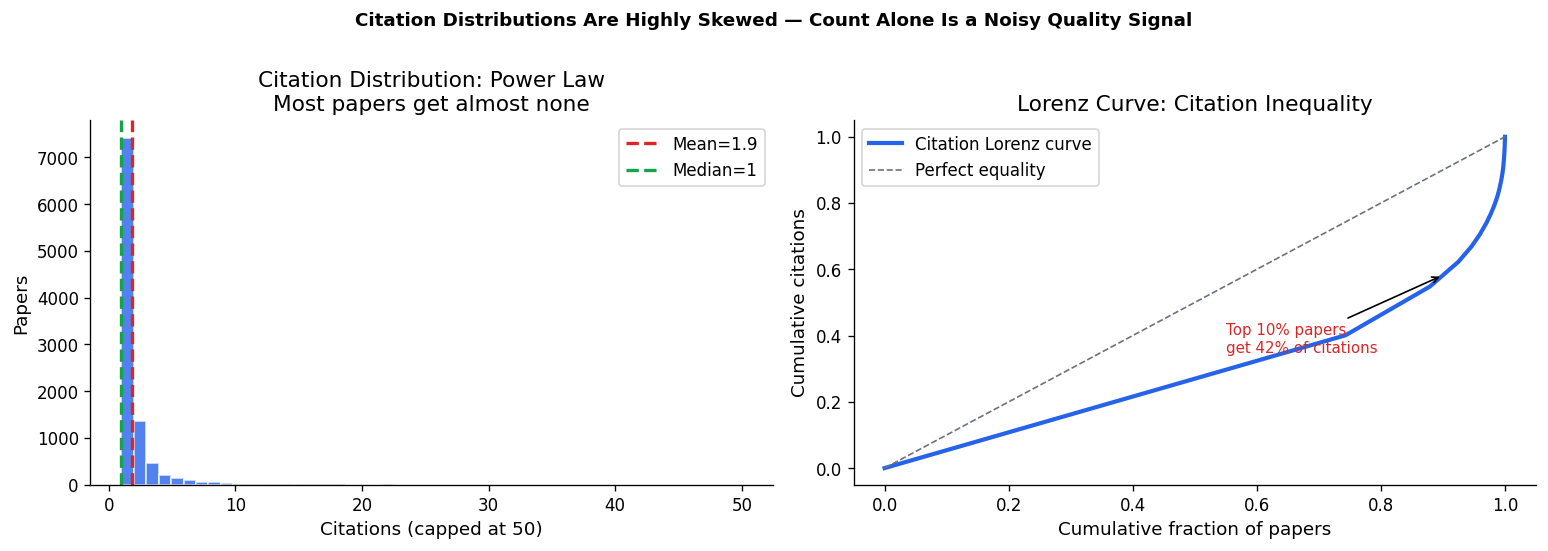

Saved.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
ax.hist(citations[citations<=50], bins=50, color=BLUE, alpha=0.8, edgecolor='white')
ax.axvline(citations.mean(),    color=RED,   lw=2, ls='--', label=f'Mean={citations.mean():.1f}')
ax.axvline(np.median(citations),color=GREEN, lw=2, ls='--', label=f'Median={np.median(citations):.0f}')
ax.set_xlabel('Citations (capped at 50)'); ax.set_ylabel('Papers')
ax.set_title('Citation Distribution: Power Law\nMost papers get almost none'); ax.legend()

ax2 = axes[1]
sorted_c = np.sort(citations)
cum_p = np.linspace(0,1,len(sorted_c))
cum_c = np.cumsum(sorted_c)/sorted_c.sum()
ax2.plot(cum_p, cum_c, color=BLUE, lw=2.5, label='Citation Lorenz curve')
ax2.plot([0,1],[0,1], color=GRAY, ls='--', lw=1, label='Perfect equality')
top10 = 1 - cum_c[int(0.9*len(sorted_c))]
ax2.annotate(f'Top 10% papers\nget {top10:.0%} of citations',
             xy=(0.9,1-top10), xytext=(0.55,0.35), fontsize=9, color=RED,
             arrowprops=dict(arrowstyle='->', color='black'))
ax2.set_xlabel('Cumulative fraction of papers'); ax2.set_ylabel('Cumulative citations')
ax2.set_title('Lorenz Curve: Citation Inequality'); ax2.legend()
plt.suptitle('Citation Distributions Are Highly Skewed — Count Alone Is a Noisy Quality Signal',
             fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/01_citations.png', bbox_inches='tight')
plt.show(); print('Saved.')

<a id='3'></a>
## 3. Peer Review as a Noisy Classifier

Reviewers are not always qualified (slides, p.11). We can model this precisely: peer review is a binary classifier that should accept high-quality papers and reject weak ones. Reviewer noise introduces false accepts and false rejects. More reviewers reduce both error types — but with diminishing returns.

In [8]:
def simulate_review(n=10000, threshold=0.7, noise=0.2, n_rev=3, seed=0):
    rng = np.random.default_rng(seed)
    quality = rng.uniform(0, 1, n)
    should = quality > threshold
    scores = np.mean([quality + rng.normal(0, noise, n) for _ in range(n_rev)], axis=0)
    accept = scores > threshold
    fp  = (accept & ~should).sum() / max((~should).sum(), 1)
    fn  = (~accept & should).sum() / max(should.sum(), 1)
    prec = (accept & should).sum() / max(accept.sum(), 1)
    return fp, fn, prec

noise_vals = [0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50]
res_n = [simulate_review(noise=s) for s in noise_vals]
rev_vals = [1, 2, 3, 4, 5, 6, 8, 10]
res_r = [simulate_review(noise=0.3, n_rev=r) for r in rev_vals]

print("Effect of reviewer noise (3 reviewers, top-30% acceptance):")
print(f"{'Noise':>8} {'False Accept':>14} {'False Reject':>14} {'Precision':>10}")
for s, (fp,fn,pr) in zip(noise_vals, res_n):
    print(f"  {s:.2f}      {fp:>12.1%}   {fn:>12.1%}   {pr:>8.1%}")

Effect of reviewer noise (3 reviewers, top-30% acceptance):
   Noise   False Accept   False Reject  Precision
  0.05              1.8%           4.4%      95.8%
  0.10              3.6%           7.7%      91.7%
  0.15              4.9%          11.6%      88.5%
  0.20              6.7%          15.7%      84.3%
  0.30              9.9%          22.4%      77.0%
  0.40             13.3%          27.6%      70.1%
  0.50             16.4%          31.7%      64.1%


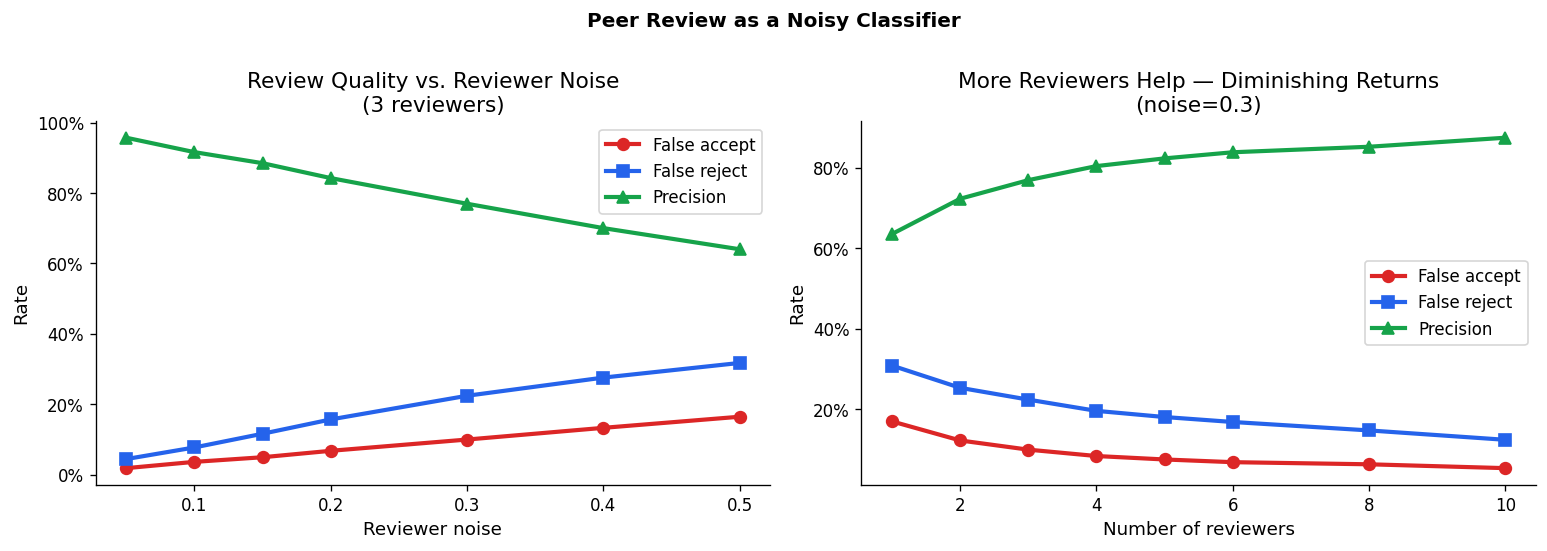

Saved.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
ax.plot(noise_vals, [r[0] for r in res_n], color=RED,   lw=2.5, marker='o', ms=7, label='False accept')
ax.plot(noise_vals, [r[1] for r in res_n], color=BLUE,  lw=2.5, marker='s', ms=7, label='False reject')
ax.plot(noise_vals, [r[2] for r in res_n], color=GREEN, lw=2.5, marker='^', ms=7, label='Precision')
ax.set_xlabel('Reviewer noise'); ax.set_ylabel('Rate')
ax.set_title('Review Quality vs. Reviewer Noise\n(3 reviewers)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1)); ax.legend()

ax2 = axes[1]
ax2.plot(rev_vals, [r[0] for r in res_r], color=RED,   lw=2.5, marker='o', ms=7, label='False accept')
ax2.plot(rev_vals, [r[1] for r in res_r], color=BLUE,  lw=2.5, marker='s', ms=7, label='False reject')
ax2.plot(rev_vals, [r[2] for r in res_r], color=GREEN, lw=2.5, marker='^', ms=7, label='Precision')
ax2.set_xlabel('Number of reviewers'); ax2.set_ylabel('Rate')
ax2.set_title('More Reviewers Help — Diminishing Returns\n(noise=0.3)')
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1)); ax2.legend()
plt.suptitle('Peer Review as a Noisy Classifier', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/02_peer_review.png', bbox_inches='tight')
plt.show(); print('Saved.')

<a id='4'></a>
## 4. Mertonian Norms → PPV: What Violations Actually Cost

Merton's four norms are ethical ideals for science. Each violation maps directly into the Ioannidis PPV model from Class 09:

| Norm | If violated | Effect on PPV model |
|------|-------------|--------------------|
| **Disinterestedness** | Financial conflicts → positive result bias | Increases bias $u$ |
| **Communality** | File drawer: negative results hidden | Reduces effective power $\gamma$ |
| **Organized skepticism** | No replication required | High $u$ persists unchecked |
| **Universalism** | Results judged by author prestige | Selection bias in publication |

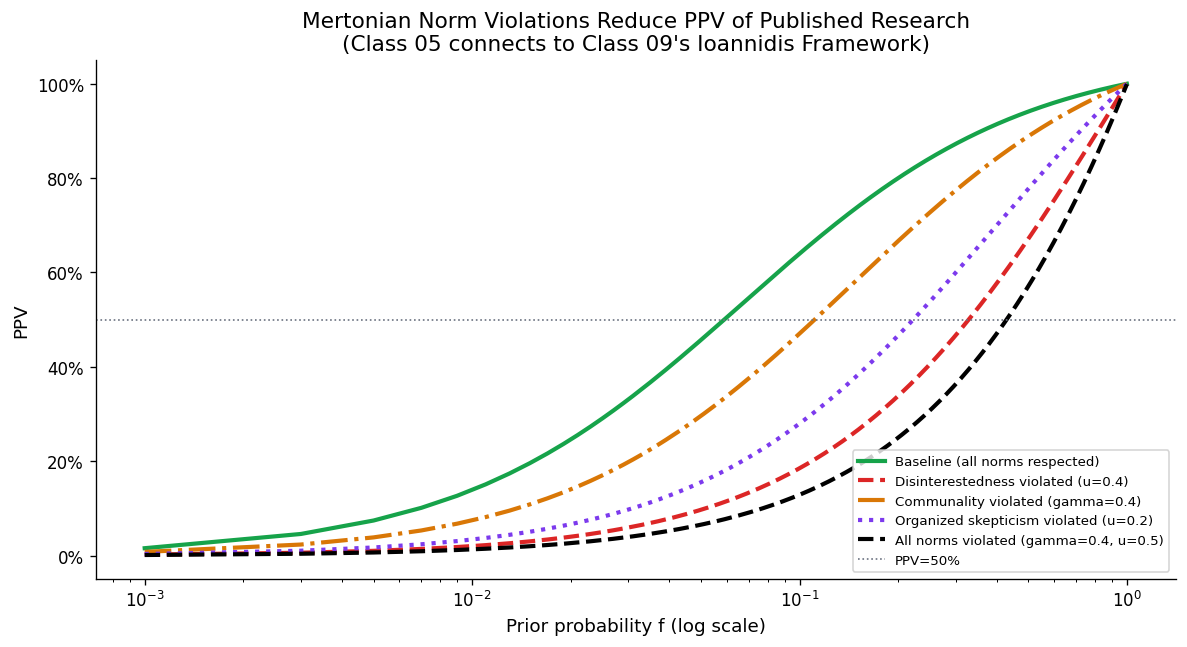

Saved.


In [10]:
def ppv(f, gamma=0.8, alpha=0.05, u=0.0):
    R = f / (1 - f)
    beta = 1 - gamma
    num = (1 - beta + u*beta) * R
    return num / (num + alpha + u*(1-alpha))

f_range = np.linspace(0.001, 0.999, 500)
scenarios = [
    ('Baseline (all norms respected)',          0.8, 0.05, 0.0,  GREEN,  '-'),
    ('Disinterestedness violated (u=0.4)',      0.8, 0.05, 0.4,  RED,    '--'),
    ('Communality violated (gamma=0.4)',        0.4, 0.05, 0.0,  ORANGE, '-.'),
    ('Organized skepticism violated (u=0.2)',   0.8, 0.05, 0.2,  PURPLE, ':'),
    ('All norms violated (gamma=0.4, u=0.5)',   0.4, 0.05, 0.5,  'black','--'),
]

fig, ax = plt.subplots(figsize=(10, 5.5))
for label, gamma, alpha, u, col, ls in scenarios:
    ax.semilogx(f_range, [ppv(f,gamma,alpha,u) for f in f_range],
                color=col, lw=2.5, ls=ls, label=label)
ax.axhline(0.5, color=GRAY, ls=':', lw=1, label='PPV=50%')
ax.set_xlabel('Prior probability f (log scale)'); ax.set_ylabel('PPV')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title("Mertonian Norm Violations Reduce PPV of Published Research\n(Class 05 connects to Class 09's Ioannidis Framework)")
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig('figures/03_mertonian_ppv.png', bbox_inches='tight')
plt.show(); print('Saved.')

<a id='5'></a>
## 5. Famous Scientific Mistakes — Failure Mode Taxonomy

The slides list classic errors. Every single one maps to a concept covered in this course. We categorize them by failure mode to make the connection explicit.

Failure mode: Confounding (smells and disease co-occur)
  Miasma theory of disease: Class 03: association != causation

Failure mode: Measurement error / wrong model
  Phlogiston theory: Falsified by Lavoisier mass measurement

Failure mode: Motivated reasoning / selective reporting
  Phrenology: Class 09: high bias u; no replication

Failure mode: No control group / survivor bias
  Bloodletting cures disease: Class 01: no control = no causal claim

Failure mode: Observer bias / instrument limits
  Martian canals: Measurement error + strong prior belief

Failure mode: Poorly controlled experiment
  Spontaneous generation: Class 01: Pasteur used proper controls

Failure mode: Prior too strong / no falsification
  Sun orbits Earth: Popper: unfalsifiable under epicycles

Failure mode: Unfalsifiable auxiliary hypotheses
  Luminiferous aether: Null result needs power (Class 08)



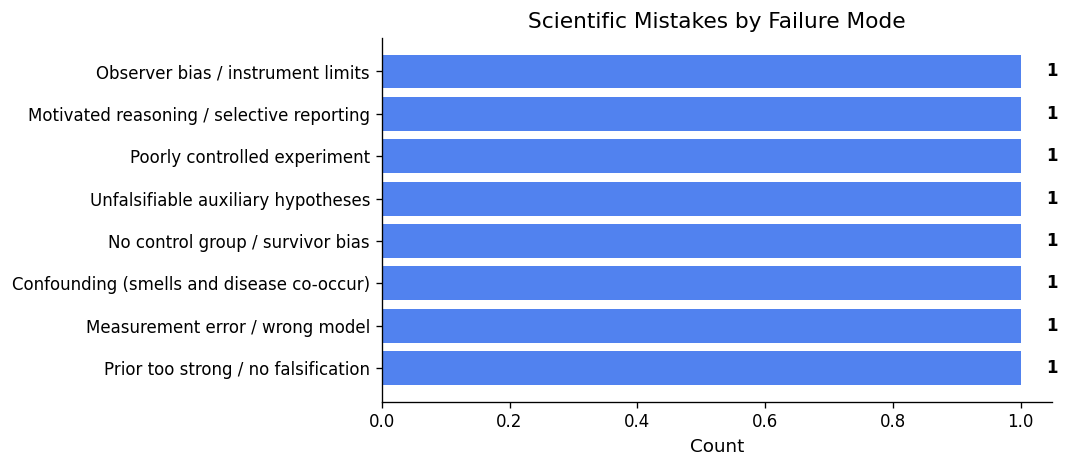

Saved.


In [11]:
mistakes = pd.DataFrame([
    {'Claim':'Sun orbits Earth',        'Failure':'Prior too strong / no falsification',
     'Connection':'Popper: unfalsifiable under epicycles'},
    {'Claim':'Phlogiston theory',       'Failure':'Measurement error / wrong model',
     'Connection':'Falsified by Lavoisier mass measurement'},
    {'Claim':'Miasma theory of disease','Failure':'Confounding (smells and disease co-occur)',
     'Connection':'Class 03: association != causation'},
    {'Claim':'Bloodletting cures disease','Failure':'No control group / survivor bias',
     'Connection':'Class 01: no control = no causal claim'},
    {'Claim':'Luminiferous aether',     'Failure':'Unfalsifiable auxiliary hypotheses',
     'Connection':'Null result needs power (Class 08)'},
    {'Claim':'Spontaneous generation',  'Failure':'Poorly controlled experiment',
     'Connection':'Class 01: Pasteur used proper controls'},
    {'Claim':'Phrenology',              'Failure':'Motivated reasoning / selective reporting',
     'Connection':'Class 09: high bias u; no replication'},
    {'Claim':'Martian canals',          'Failure':'Observer bias / instrument limits',
     'Connection':'Measurement error + strong prior belief'},
])

for mode, grp in mistakes.groupby('Failure'):
    print(f"Failure mode: {mode}")
    for _, r in grp.iterrows():
        print(f"  {r.Claim}: {r.Connection}")
    print()

mode_counts = mistakes['Failure'].value_counts()
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(mode_counts.index, mode_counts.values, color=BLUE, alpha=0.8)
ax.set_xlabel('Count'); ax.set_title("Scientific Mistakes by Failure Mode")
for bar, val in zip(bars, mode_counts.values):
    ax.text(bar.get_width()+0.04, bar.get_y()+bar.get_height()/2,
            str(val), va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('figures/04_mistakes.png', bbox_inches='tight')
plt.show(); print('Saved.')

<a id='6'></a>
## 6. Popper's Falsifiability — Quantified

Popper's insight: a claim must be *disprovable* to be scientific. In the Ioannidis model, **unfalsifiability = high bias $u$** — if researchers can always add an auxiliary hypothesis to save a failed theory, it's equivalent to every failed experiment still being reported as support. We simulate replication rates under increasing 'theoretical flexibility'.

In [12]:
# Popper: unfalsifiability == high u in the Ioannidis model
# Simulate original study + replications under varying bias u
def replication_rate(u=0.0, f=0.2, gamma=0.8, alpha=0.05, n=2000, n_rep=3, seed=0):
    rng = np.random.default_rng(seed)
    is_true = rng.random(n) < f
    def pval(true_effect):
        z = rng.normal(float(true_effect)*np.sqrt(50), 1)
        if rng.random() < u:
            return rng.uniform(0, alpha)
        return 2*(1 - stats.norm.cdf(abs(z)))
    orig = np.array([pval(t) for t in is_true])
    sig  = orig < alpha
    reps = np.array([[pval(t) for _ in range(n_rep)] for t in is_true])
    rep_sig = (reps < alpha).all(axis=1)
    rep_rate = rep_sig[sig].mean() if sig.sum() > 0 else 0.0
    fdr_val  = (~is_true[sig]).mean() if sig.sum() > 0 else 0.0
    return rep_rate, fdr_val

u_vals = np.linspace(0, 0.8, 20)
rr_vals, fdr_vals = zip(*[replication_rate(u=u, seed=int(u*1000)) for u in u_vals])

print(f"{'Bias u':>8} {'Replication rate':>18} {'FDR':>10}")
for u, rr, fdr in zip(u_vals[::4], rr_vals[::4], fdr_vals[::4]):
    print(f"  {u:.2f}     {rr:>14.1%}     {fdr:>8.1%}")

  Bias u   Replication rate        FDR
  0.00              81.5%        18.5%
  0.17              54.7%        45.9%
  0.34              45.1%        58.1%
  0.51              39.9%        69.2%
  0.67              49.3%        73.4%


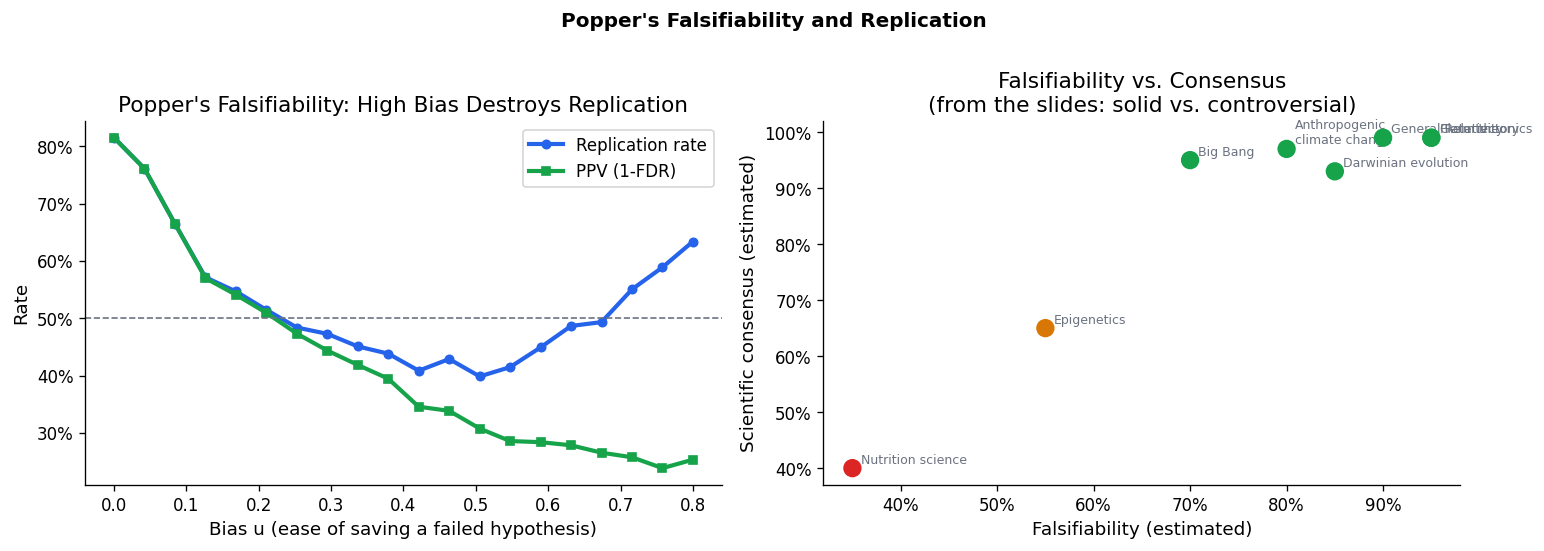

Saved.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
ax.plot(u_vals, rr_vals,  color=BLUE,  lw=2.5, marker='o', ms=5, label='Replication rate')
ax.plot(u_vals, [1-f for f in fdr_vals], color=GREEN, lw=2.5,
        marker='s', ms=5, label='PPV (1-FDR)')
ax.axhline(0.5, color=GRAY, ls='--', lw=1)
ax.set_xlabel('Bias u (ease of saving a failed hypothesis)')
ax.set_ylabel('Rate')
ax.set_title("Popper's Falsifiability: High Bias Destroys Replication")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1)); ax.legend()

ax2 = axes[1]
topics = ['Plate tectonics','General Relativity','Germ theory',
          'Big Bang','Darwinian evolution','Anthropogenic\nclimate change',
          'Epigenetics','Nutrition science']
consensus  = [0.99, 0.99, 0.99, 0.95, 0.93, 0.97, 0.65, 0.40]
falsifiab  = [0.95, 0.90, 0.95, 0.70, 0.85, 0.80, 0.55, 0.35]
colors_c   = [GREEN if c>0.9 else ORANGE if c>0.6 else RED for c in consensus]
ax2.scatter(falsifiab, consensus, c=colors_c, s=100, zorder=5)
for t, f, c in zip(topics, falsifiab, consensus):
    ax2.annotate(t, (f,c), textcoords='offset points', xytext=(5,3), fontsize=7.5, color=GRAY)
ax2.set_xlabel('Falsifiability (estimated)'); ax2.set_ylabel('Scientific consensus (estimated)')
ax2.set_title('Falsifiability vs. Consensus\n(from the slides: solid vs. controversial)')
ax2.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.suptitle("Popper's Falsifiability and Replication", fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/05_popper.png', bbox_inches='tight')
plt.show(); print('Saved.')

<a id='7'></a>
## 7. Course Synthesis — Every Class in the Scientific Process

The slides frame science as iterative and social. Each class in this course is a defense against a specific failure mode in that process.

In [14]:
course_map = pd.DataFrame([
    {'Class':'01','Topic':'Experimental Design',
     'Role in Science':'How to design valid studies',
     'Failure prevented':'No control group, confounding, ordering effects'},
    {'Class':'02','Topic':'Causal Inference',
     'Role in Science':'What experiments can and cannot prove',
     'Failure prevented':'Selection bias, vitamin C fallacy'},
    {'Class':'03','Topic':'Observational Studies',
     'Role in Science':'When experiments are impossible',
     'Failure prevented':'Miasma/bloodletting: association != causation'},
    {'Class':'04','Topic':'P-values & CIs',
     'Role in Science':'How to quantify evidence',
     'Failure prevented':'P-value misinterpretation, dichotomous thinking'},
    {'Class':'05','Topic':'How Science Works',
     'Role in Science':'The social and institutional context',
     'Failure prevented':'Peer review failure, funding bias, norm violations'},
    {'Class':'08','Topic':'Multiple Testing',
     'Role in Science':'Controlling false discovery at scale',
     'Failure prevented':'Genome-wide false positives, fishing expeditions'},
    {'Class':'09','Topic':'Why Findings Are False',
     'Role in Science':'Quantifying research reliability',
     'Failure prevented':'Replication crisis, publication bias'},
    {'Class':'10','Topic':'Distribution Shift',
     'Role in Science':'Generalization beyond the lab',
     'Failure prevented':'Model deployment failures, WEIRD samples'},
])
pd.set_option('display.max_colwidth', 60)
print(course_map.to_string(index=False))

Class                  Topic                       Role in Science                                  Failure prevented
   01    Experimental Design           How to design valid studies    No control group, confounding, ordering effects
   02       Causal Inference What experiments can and cannot prove                  Selection bias, vitamin C fallacy
   03  Observational Studies       When experiments are impossible      Miasma/bloodletting: association != causation
   04         P-values & CIs              How to quantify evidence    P-value misinterpretation, dichotomous thinking
   05      How Science Works  The social and institutional context Peer review failure, funding bias, norm violations
   08       Multiple Testing  Controlling false discovery at scale   Genome-wide false positives, fishing expeditions
   09 Why Findings Are False      Quantifying research reliability               Replication crisis, publication bias
   10     Distribution Shift         Generalization beyo

---

## 📝 Key Takeaways

| Concept | What to Remember |
|---------|------------------|
| **Science is social** | Results accepted after peer review + replication — both are imperfect |
| **Citation inequality** | Power-law: top 10% of papers get most citations; count ≠ quality |
| **Peer review as classifier** | False accept + false reject rates; more reviewers help with diminishing returns |
| **Mertonian norms** | Each violation has a quantifiable cost: higher $u$ or lower $\gamma$ in PPV |
| **Scientific mistakes** | Trace to: wrong prior, no control, confounding, measurement error, motivated reasoning |
| **Popper's falsifiability** | Unfalsifiable claims accumulate; replication is the empirical enforcement mechanism |
| **Consensus** | Earned through high falsifiability + repeated failed attempts to disprove |

---

## 📚 References

- Ritchie, S. (2020). *Science Fictions.* Metropolitan Books.
- Merton, R.K. (1942). *The Normative Structure of Science.*
- Popper, K. (1959). *The Logic of Scientific Discovery.* Basic Books.
- Lotka, A.J. (1926). *The frequency distribution of scientific productivity.* J. Washington Academy of Sciences.
- Ioannidis, J.P.A. (2005). *Why Most Published Research Findings Are False.* PLOS Medicine.

---
*DSC 215 · UCSD · Spring 2026 · Prof. Armin Schwartzman*